In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
path=r"C:\Users\piyus\Desktop\Desk Top\02-04-2026 Mess to sort out\Project 02 European Bank\European_Bank.csv"
df=pd.read_csv(path)
print("Loaded Dataset sucessfully!")

Loaded Dataset sucessfully!


# High Value Customer Churn Analyss

In [4]:
df.columns

Index(['Year', 'Customer Id', 'Surname', 'Credit Score', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'Number Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary', 'Exited'],
      dtype='object')

In [5]:
# 1. Balance Tier (EU €100k+ = affluent threshold)
df['Balance_Tier'] = pd.cut(df['Balance'],
    bins=[0, 50000, 100000, 150000, float('inf')],
    labels=[0, 1, 2, 3]).astype(float)

# 2. Relationship Depth (multi-product = sticky)
df['Deep_Relationship'] = (df['Number Of Products'] >= 2).astype(int)

# 3. Profitable Active (EU upper-middle salary ~75k)
df['Profitable_Active'] = (
    (df['Is Active Member'] == 1) &
    (df['Estimated Salary'] >= 75000)
).astype(int)

# 4. Loyal Customer (5+ years = retained)
df['Is_Loyal'] = (df['Tenure'] >= 5).astype(int)

# 5. Credit Worthy (Good credit score EU standard 700+)
df['Credit_Worthy'] = (df['Credit Score'] >= 700).astype(int)

# 6. HVC Composite Score
df['HVC_Score'] = (
    df['Balance_Tier'] / 3       * 0.35 +   # Wealth
    df['Deep_Relationship']       * 0.25 +   # Engagement
    df['Profitable_Active']       * 0.20 +   # Activity
    df['Credit_Worthy']           * 0.12 +   # Creditworthiness
    df['Is_Loyal']                * 0.08     # Tenure
)

# 7. EU Bank Segments
df['Customer_Segment'] = pd.cut(df['HVC_Score'],
    bins=[-0.01, 0.2, 0.5, 0.75, 1.01],
    labels=['Standard', 'Silver', 'Gold', 'Private Banking'])

In [6]:
df[['Credit Score','Tenure', 'Balance', 'Number Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary']].describe()

,Credit Score,Tenure,Balance,Number Of Products,Has Credit Card,Is Active Member,Estimated Salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,650.528800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881
std,96.653299,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818
min,350.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000
25%,584.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000
50%,652.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000
75%,718.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500
max,850.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000


In [7]:
import pandas as pd

# --- Feature Engineering (from previous steps) ---
df['Balance_Tier'] = pd.cut(df['Balance'],
    bins=[0, 50000, 100000, 150000, float('inf')],
    labels=[0, 1, 2, 3]).astype(float)

df['Deep_Relationship'] = (df['Number Of Products'] >= 2).astype(int)
df['Profitable_Active']  = ((df['Is Active Member'] == 1) & (df['Estimated Salary'] >= 75000)).astype(int)
df['Is_Loyal']           = (df['Tenure'] >= 5).astype(int)
df['Credit_Worthy']      = (df['Credit Score'] >= 700).astype(int)

df['HVC_Score'] = (
    df['Balance_Tier'] / 3  * 0.35 +
    df['Deep_Relationship'] * 0.25 +
    df['Profitable_Active'] * 0.20 +
    df['Credit_Worthy']     * 0.12 +
    df['Is_Loyal']          * 0.08
)

df['Customer_Segment'] = pd.cut(df['HVC_Score'],
    bins=[-0.01, 0.2, 0.5, 0.75, 1.01],
    labels=['Standard', 'Silver', 'Gold', 'Private Banking'])

# --- Churn Analysis Across All Dimensions ---

print("=== OVERALL CHURN ===")
print(df['Exited'].value_counts(normalize=True).mul(100).round(1))

print("\n=== BY SEGMENT ===")
print(df.groupby('Customer_Segment')['Exited'].mean().mul(100).round(1))

print("\n=== BY GEOGRAPHY ===")
print(df.groupby('Geography')['Exited'].mean().mul(100).round(1))

print("\n=== BY GENDER ===")
print(df.groupby('Gender')['Exited'].mean().mul(100).round(1))

print("\n=== BY NUMBER OF PRODUCTS ===")
print(df.groupby('Number Of Products')['Exited'].mean().mul(100).round(1))

print("\n=== BY ACTIVE MEMBER ===")
print(df.groupby('Is Active Member')['Exited'].mean().mul(100).round(1))

print("\n=== BY AGE BAND ===")
df['Age_Band'] = pd.cut(df['Age'], bins=[0,30,45,60,100],
                        labels=['<30','30-45','45-60','60+'])
print(df.groupby('Age_Band')['Exited'].mean().mul(100).round(1))

print("\n=== BY CREDIT SCORE BAND ===")
df['CS_Band'] = pd.cut(df['Credit Score'], bins=[0,500,600,700,850],
                       labels=['<500','500-600','600-700','700+'])
print(df.groupby('CS_Band')['Exited'].mean().mul(100).round(1))

=== OVERALL CHURN ===
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64

=== BY SEGMENT ===
Customer_Segment
Standard           25.4
Silver             27.1
Gold               20.3
Private Banking    16.8
Name: Exited, dtype: float64

=== BY GEOGRAPHY ===
Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Exited, dtype: float64

=== BY GENDER ===
Gender
Female    25.1
Male      16.5
Name: Exited, dtype: float64

=== BY NUMBER OF PRODUCTS ===
Number Of Products
1     27.7
2      7.6
3     82.7
4    100.0
Name: Exited, dtype: float64

=== BY ACTIVE MEMBER ===
Is Active Member
0    26.9
1    14.3
Name: Exited, dtype: float64

=== BY AGE BAND ===
Age_Band
<30       7.5
30-45    15.7
45-60    51.1
60+      24.8
Name: Exited, dtype: float64

=== BY CREDIT SCORE BAND ===
CS_Band
<500       23.6
500-600    21.2
600-700    19.7
700+       19.9
Name: Exited, dtype: float64


C:\Users\piyus\AppData\Local\Temp\ipykernel_19172\3005102246.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Customer_Segment')['Exited'].mean().mul(100).round(1))
C:\Users\piyus\AppData\Local\Temp\ipykernel_19172\3005102246.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age_Band')['Exited'].mean().mul(100).round(1))
C:\Users\piyus\AppData\Local\Temp\ipykernel_19172\3005102246.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 

In [8]:
import pandas as pd
import numpy as np

features = [
    'Credit Score', 'Tenure', 'Balance',
    'Number Of Products', 'Has Credit Card',
    'Is Active Member', 'Estimated Salary'
]

# 1. Z-Score normalize each feature
for col in features:
    df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()

# 2. Weights — banking profit logic
weights = {
    'Credit Score_z':        0.20,  # creditworthiness = risk cost
    'Tenure_z':              0.10,  # loyalty = retention value
    'Balance_z':             0.30,  # AUM = direct profit driver
    'Number Of Products_z':  0.20,  # cross-sell = revenue depth
    'Has Credit Card_z':     0.05,  # fee income
    'Is Active Member_z':    0.10,  # engagement = lower churn cost
    'Estimated Salary_z':    0.05   # upsell potential
}

# 3. Composite Score
df['Customer_Value_Score'] = sum(
    df[col] * w for col, w in weights.items()
)

# 4. Normalize to 0–100 for readability
df['CVS_0_100'] = (
    (df['Customer_Value_Score'] - df['Customer_Value_Score'].min()) /
    (df['Customer_Value_Score'].max() - df['Customer_Value_Score'].min())
) * 100

# 5. Segment
df['Value_Tier'] = pd.cut(df['CVS_0_100'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Premium'])

# 6. Sanity check
print(df[['CVS_0_100', 'Value_Tier']].describe())
print(df['Value_Tier'].value_counts())

          CVS_0_100
count  10000.000000
mean      46.099412
std       13.096861
min        0.000000
25%       37.085538
50%       45.842492
75%       54.681188
max      100.000000
Value_Tier
Medium     5755
High       3590
Low         479
Premium     175
Name: count, dtype: int64


In [9]:
df.columns

Index(['Year', 'Customer Id', 'Surname', 'Credit Score', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'Number Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary', 'Exited', 'Balance_Tier',
       'Deep_Relationship', 'Profitable_Active', 'Is_Loyal', 'Credit_Worthy',
       'HVC_Score', 'Customer_Segment', 'Age_Band', 'CS_Band',
       'Credit Score_z', 'Tenure_z', 'Balance_z', 'Number Of Products_z',
       'Has Credit Card_z', 'Is Active Member_z', 'Estimated Salary_z',
       'Customer_Value_Score', 'CVS_0_100', 'Value_Tier'],
      dtype='object')

In [10]:
hdf=df[['Year', 'Customer Id', 'Surname', 'Credit Score', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'Number Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary', 'Exited'
       , 'CVS_0_100', 'Value_Tier']]

In [11]:
print("labels=['Low', 'Medium', 'High', 'Premium'])")

labels=['Low', 'Medium', 'High', 'Premium'])


In [26]:
Geography=["France", "Spain", "Germany"]
filters=['Low', 'Medium', 'High', 'Premium']


for g in Geography:
    print("\n")
    print(f"{g}")
    print("\n")
    for x in filters:
        print(f"{x}")
        
        print(df[(df["Value_Tier"] == f"{x}")&(df["Exited"] == 1)&(df["Geography"] == f"{g}")].shape[0])
   



France


Low
95
Medium
446
High
236
Premium
32


Spain


Low
49
Medium
218
High
133
Premium
13


Germany


Low
7
Medium
403
High
354
Premium
50


In [16]:
Labels=['Low','Medium','High','Premium']
t_p=[479,5755,3590,175]
c_p=[151,1067,723,95]

Segment  Total  Churned  Retained  Churn Rate %  Retention Rate %
    Low    479      151       328          31.5              68.5
 Medium   5755     1067      4688          18.5              81.5
   High   3590      723      2867          20.1              79.9
Premium    175       95        80          54.3              45.7


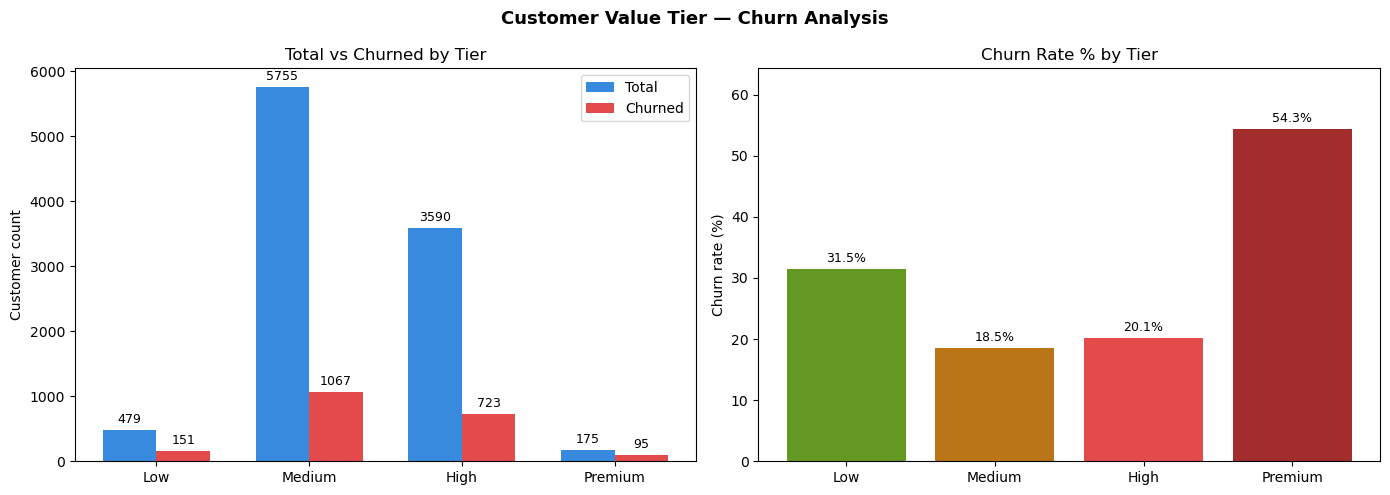

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
labels    = ['Low', 'Medium', 'High', 'Premium']
total     = [df[df['Value_']], 5755, 3590, 175]
churned   = [151, 1067, 723, 95]

retained       = [t - c for t, c in zip(total, churned)]
churn_rate     = [round(c/t*100, 1) for c, t in zip(churned, total)]
retention_rate = [round(r/t*100, 1) for r, t in zip(retained, total)]

df_tier = pd.DataFrame({
    'Segment':        labels,
    'Total':          total,
    'Churned':        churned,
    'Retained':       retained,
    'Churn Rate %':   churn_rate,
    'Retention Rate %': retention_rate
})

print(df_tier.to_string(index=False))

# --- Plot ---
x   = np.arange(len(labels))
w   = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Total vs Churned (grouped bar)
ax1 = axes[0]
b1  = ax1.bar(x - w/2, total,   w, label='Total',   color='#378ADD')
b2  = ax1.bar(x + w/2, churned, w, label='Churned', color='#E24B4A')
ax1.bar_label(b1, padding=3, fontsize=9)
ax1.bar_label(b2, padding=3, fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title('Total vs Churned by Tier')
ax1.legend()
ax1.set_ylabel('Customer count')

# Chart 2 — Churn Rate % per tier
ax2    = axes[1]
colors = ['#639922', '#BA7517', '#E24B4A', '#A32D2D']
bars   = ax2.bar(labels, churn_rate, color=colors)
ax2.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax2.set_title('Churn Rate % by Tier')
ax2.set_ylabel('Churn rate (%)')
ax2.set_ylim(0, max(churn_rate) + 10)

plt.suptitle('Customer Value Tier — Churn Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df['']